In [16]:
# In questo notepad verrà definita l'architettura dell GCN.
# L'obiettivo è produrre degli embedding sul quale fare clustering.

from torch_geometric.data import Data
import torch

OUTPUT_PATH = './model_output'

pre_processed_data_path = f'{OUTPUT_PATH}/pre_processed_data.pt'
data = torch.load(pre_processed_data_path)

edge_index = data['edge_index']
node_features = data['node_features']
node_ids = data['node_ids']

data = Data(x=node_features, edge_index=edge_index)
print(data)

Data(x=[178, 200], edge_index=[2, 663])


In [17]:
print("Numero totale di nodi in x:", node_features.shape[0])  # Deve essere 178
print("Massimo ID presente in edge_index:", edge_index.max().item())  # Non deve essere >= 178
print("Minimo ID presente in edge_index:", edge_index.min().item())  # Non deve essere < 0


Numero totale di nodi in x: 178
Massimo ID presente in edge_index: 177
Minimo ID presente in edge_index: 0


In [18]:
# Definizione architettura

import torch.nn.functional as F
from torch_geometric.nn import GCNConv

class GCN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, embedding_dim):
        super(GCN, self).__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)  # Primo strato di convoluzione
        self.conv2 = GCNConv(hidden_channels, embedding_dim)  # Strato finale per generare gli embedding

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = self.conv1(x, edge_index)
        x = F.relu(x)  # Attivazione non lineare
        x = self.conv2(x, edge_index)  # Gli embedding finali
        return x  # Ritorniamo direttamente gli embedding

# Inizializziamo il modello
model = GCN(in_channels=node_features.shape[1], hidden_channels=64, embedding_dim=16)

print(model)


GCN(
  (conv1): GCNConv(200, 64)
  (conv2): GCNConv(64, 16)
)


In [ ]:
# Training

import torch.optim as optim
from tqdm import tqdm

optimizer = optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)

# Loss basata sulla similarità dei nodi connessi
def unsupervised_loss(embeddings, edge_index):
    node1 = embeddings[edge_index[0]]
    node2 = embeddings[edge_index[1]]
    return F.mse_loss(node1, node2)

num_epochs = 100
with tqdm(total=num_epochs, desc="Training Progress", unit="epoch") as pbar:
    for epoch in range(num_epochs):
        model.train()
        optimizer.zero_grad()
        embeddings = model(data)
        loss = unsupervised_loss(embeddings, data.edge_index)
        loss.backward()
        optimizer.step()

        pbar.set_postfix(loss=loss.item())
        pbar.update(1)

model.eval()  # Disattiviamo dropout e batch norm
embeddings = model(data)  # Otteniamo gli embedding finali

print("Shape degli Embedding:", embeddings.shape)
print("Embedding di esempio:", embeddings[0])

import numpy as np

np.savez(f"{OUTPUT_PATH}/embeddings.npz", embeddings=embeddings.detach().cpu().numpy())
print("Embeddings salvati in `embeddings.npz`")

Training Progress: 100%|██████████| 100/100 [00:00<00:00, 218.47epoch/s, loss=2.58e-17]


Shape degli Embedding: torch.Size([178, 16])
Embedding di esempio: tensor([ 2.1747e-05, -3.3007e-05,  3.9082e-05,  2.7840e-05,  3.9063e-05,
         3.2452e-05,  6.1581e-06, -2.8469e-05,  3.9110e-05,  1.2513e-05,
         1.2894e-05,  1.1682e-05, -3.2655e-05,  3.8974e-05,  3.9087e-05,
        -2.5590e-05], grad_fn=<SelectBackward0>)


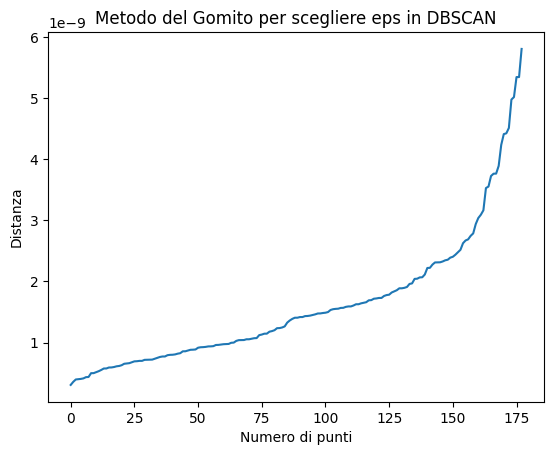

In [ ]:
# Cerco un valore ottimale per il parametro eps di DBSCAN usando la tecnica dell'elbow point

from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA

pca = PCA(n_components=2)
embeddings_pca = pca.fit_transform(embeddings.detach().cpu().numpy())

neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(embeddings_pca)
distances, indices = neighbors_fit.kneighbors(embeddings_pca)

# Ordiniamo le distanze del 5° vicino più vicino
distances = np.sort(distances[:, 4], axis=0)

plt.plot(distances)
plt.xlabel("Numero di punti")
plt.ylabel("Distanza")
plt.title("Metodo del Gomito per scegliere eps in DBSCAN")
plt.show()


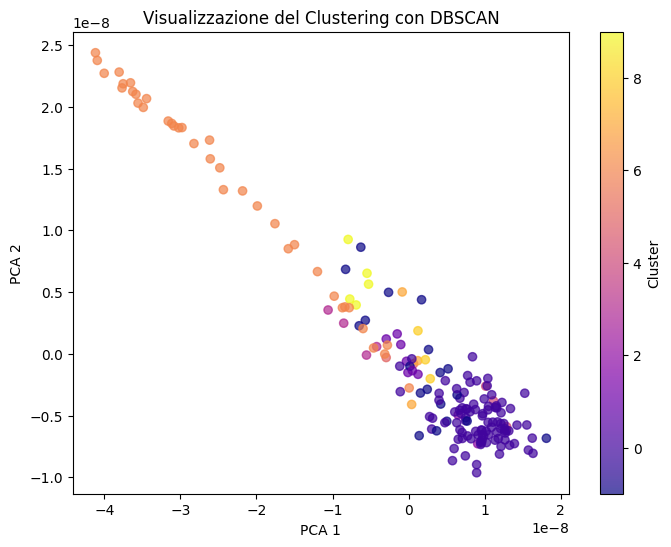

Numero di punti per cluster
0)	93
1)	7
2)	2
3)	4
4)	3
5)	2
6)	37
7)	3
8)	3
noise)	19


In [ ]:
# Applico DBSCAN e visualizzo con PCA

from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA

dbscan = DBSCAN(eps=1e-8, min_samples=2)
# dbscan = DBSCAN(eps=2.5e-9, min_samples=3)
clusters = dbscan.fit_predict(embeddings.detach().cpu().numpy())

pca = PCA(n_components=2)
embeddings_2D = pca.fit_transform(embeddings.detach().cpu().numpy())

plt.figure(figsize=(8,6))
plt.scatter(embeddings_2D[:, 0], embeddings_2D[:, 1], c=clusters, cmap="plasma", alpha=0.7)
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Visualizzazione del Clustering con DBSCAN")
plt.colorbar(label="Cluster")
plt.show()

print("Numero di punti per cluster")
for i in range(max(clusters)):
    print(f"{i})\t{len(clusters[clusters == i])}")

print(f"noise)\t{len(clusters[clusters == -1])}")

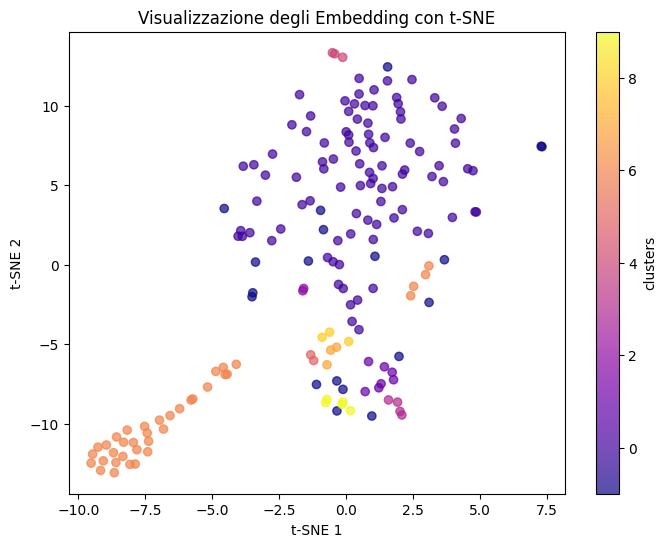

In [ ]:
# Applico DBSCAN e visualizzo con t-SNE

from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, perplexity=30, random_state=42)
embeddings_2D = tsne.fit_transform(embeddings.detach().cpu().numpy())

plt.figure(figsize=(8, 6))
plt.scatter(embeddings_2D[:, 0], embeddings_2D[:, 1], alpha=0.7, cmap="plasma", c=clusters)
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("Visualizzazione degli Embedding con t-SNE")
plt.colorbar(label='clusters')
plt.show()